In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.special import expit
from utils import decorate

sns.set_style('darkgrid')

## 16.2 The Space Shuttle Problem

In [3]:
data = pd.read_csv('./data/challenger_data.csv', parse_dates=[0])

# avoiding column names with spaces
data.rename(columns={'Damage Incident': 'Damage'}, inplace=True)

# dropping row 3, in which Damage Incident is NaN,
# and row 24, which is the record for the Challenger
data.drop(labels=[3, 24], inplace=True)

# convert the Damage column to integer
data['Damage'] = data['Damage'].astype(int)

data

,Date,Temperature,Damage
0,04/12/1981,66,0
1,11/12/1981,70,1
2,3/22/82,69,0
4,01/11/1982,68,0
5,04/04/1983,67,0
6,6/18/83,72,0
7,8/30/83,73,0
8,11/28/83,70,0
9,02/03/1984,57,1
10,04/06/1984,63,1


In [4]:
len(data), data['Damage'].sum()

(23, 7)

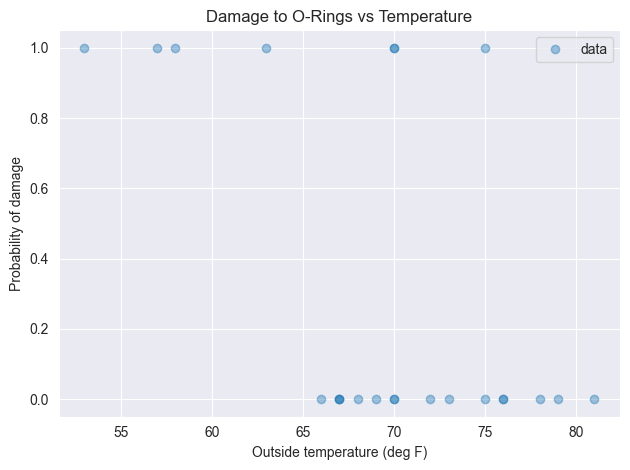

In [8]:
def plot_data(data):
    """Plot damage as a function of temperature.
    
    data: DataFrame
    """
    plt.plot(
        data['Temperature'], data['Damage'], 'o', 
        label='data', color='C0', alpha=0.4
    )

    decorate(
        ylabel="Probability of damage",
        xlabel="Outside temperature (deg F)",
        title="Damage to O-Rings vs Temperature"
    )

plot_data(data)

In [9]:
offset = data['Temperature'].mean().round()
data['x'] = data['Temperature'] - offset
data['y'] = data['Damage']

In [11]:
formula = 'y ~ x'
results = smf.logit(formula, data=data).fit(disp=False)
results.params

Intercept   -1.208490
x           -0.232163
dtype: float64

In [15]:
inter = results.params['Intercept']
slope = results.params['x']
xs = np.arange(53, 83) - offset
log_odds = inter + slope * xs
ps = expit(log_odds)

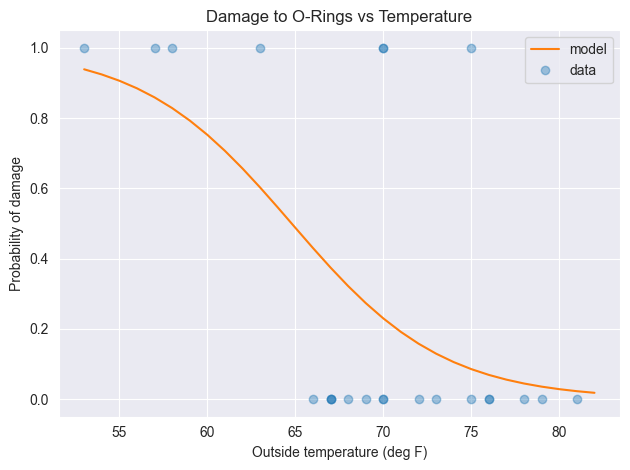

In [16]:
plt.plot(xs + offset, ps, label='model', color='C1')
plot_data(data)